<a href="https://colab.research.google.com/github/realclovisworld/Neural_Networks/blob/main/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 4

**(Qn)** Desgin and implement a CNN model(with 4+ layers of convolutions) to classify multi category image datasets. use the MNIST, Fashion MNIST, CIFAR-10 datasets. set the number of epochs as 5, 10 and 20. make the necessary changes whenever required. record the accuracy corresponding to the number of epochs. record the time required to run the program, using CPU as well as using GPU in colab

# STEPS



1. Import packages  
2. Load the MNIST dataset
3. Data normalisation/ Preprocessing
4. Define CNN architecture
5. Define loss, optimizer,
6. Train the model
7. Evaluate



In [ ]:
#using fashion mnist dataset
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
#load fashion mnist dataset
(X_train_fashion_mnist, y_train_fashion_mnist), (X_test_fashion_mnist, y_test_fashion_mnist) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#fashion_mnist shape
print('X_train_fashion_mnist.shape', X_train_fashion_mnist.shape)
print('X_test_fashion_mnist.shape', X_test_fashion_mnist.shape)
print('y_train_fashion_mnist.shape', y_train_fashion_mnist.shape)
print('y_test_fashion_mnist.shape', y_test_fashion_mnist.shape)

X_train_fashion_mnist.shape (60000, 28, 28)
X_test_fashion_mnist.shape (10000, 28, 28)
y_train_fashion_mnist.shape (60000,)
y_test_fashion_mnist.shape (10000,)


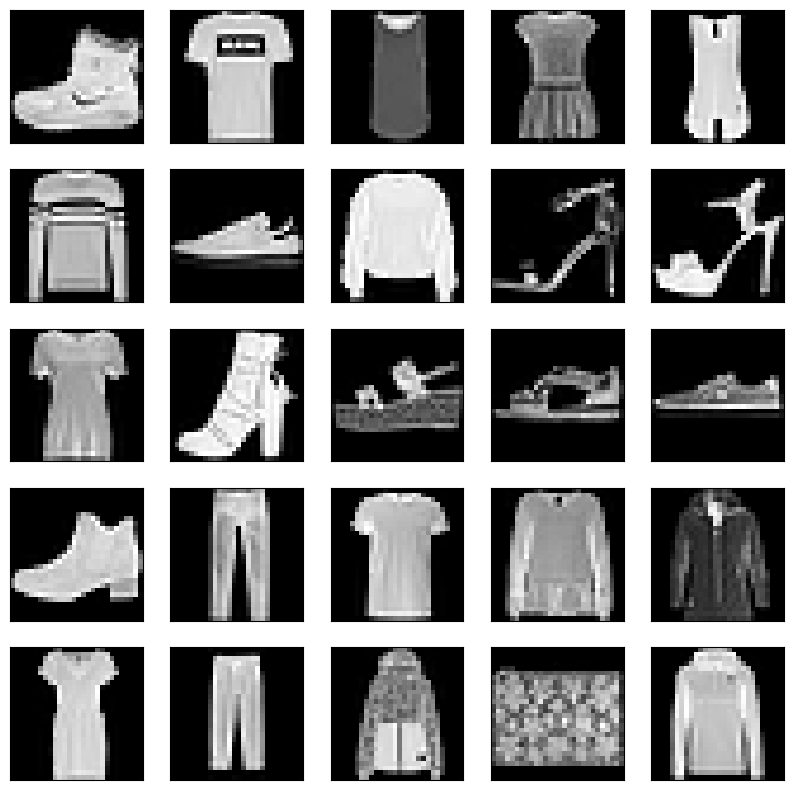

In [ ]:
# display sample images
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train_fashion_mnist[i], cmap='gray')

plt.show()

In [ ]:

#reshape
X_train_fashion_mnist = X_train_fashion_mnist.reshape(-1, 28, 28, 1)
X_test_fashion_mnist = X_test_fashion_mnist.reshape(-1, 28, 28, 1)

#type
X_train_fashion_mnist = X_train_fashion_mnist.astype('float32')/255
X_test_fashion_mnist = X_test_fashion_mnist.astype('float32')/255

#normalize
y_train_fashion_mnist_one_hot = tf.keras.utils.to_categorical(y_train_fashion_mnist)
y_test_fashion_mnist_one_hot = tf.keras.utils.to_categorical(y_test_fashion_mnist)

#print shape
print('X_train_fashion_mnist.shape', X_train_fashion_mnist.shape)
print('X_test_fashion_mnist.shape', X_test_fashion_mnist.shape)

X_train_fashion_mnist.shape (60000, 28, 28, 1)
X_test_fashion_mnist.shape (10000, 28, 28, 1)


In [ ]:
#Model Architecture

model = Sequential()

model.add(Conv2D(256, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))

model.add(Conv2D(32, (3, 3), activation='relu'))


model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 256)    │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 1, 1, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,618 (1.50 MB)

 Trainable params: 392,618 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#compile the model

print('compiling the model')
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print('model compilied')

compiling the model
model compilied


In [ ]:
#train the model
history_X_train_fashion_mnist = model.fit(
     X_train_fashion_mnist, y_train_fashion_mnist_one_hot,
     epochs=5,
     batch_size=128,
     validation_data = (X_test_fashion_mnist, y_test_fashion_mnist_one_hot)
     )

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9862 - loss: 0.0380 - val_accuracy: 0.9070 - val_loss: 0.5540
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9870 - loss: 0.0346 - val_accuracy: 0.9116 - val_loss: 0.5181
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9867 - loss: 0.0363 - val_accuracy: 0.9049 - val_loss: 0.5311
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9868 - loss: 0.0343 - val_accuracy: 0.9069 - val_loss: 0.5449
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9879 - loss: 0.0336 - val_accuracy: 0.9046 - val_loss: 0.5496


In [ ]:
#evaluate and record accuracy

test_loss, test_acc = model.evaluate(X_test_fashion_mnist, y_test_fashion_mnist_one_hot)
print('Test accuracy:', test_acc)
print('Test Loss:',test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9046 - loss: 0.5496
Test accuracy: 0.9046000242233276
Test Loss: 0.5496127009391785


In [ ]:
#prediction and visual

predictions = model.predict(X_test_fashion_mnist)
print(np.argmax(np.round(predictions[1])))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
2


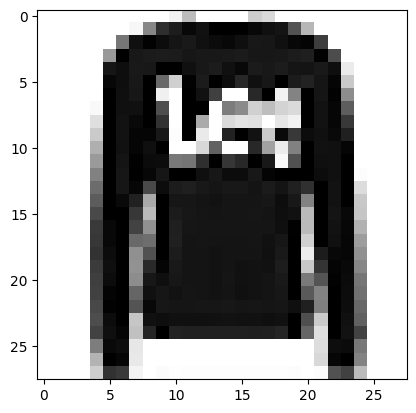

In [ ]:
#Plot the prediction

plt.imshow(X_test_fashion_mnist[1].reshape(28, 28), cmap= plt.cm.binary)
plt.show()

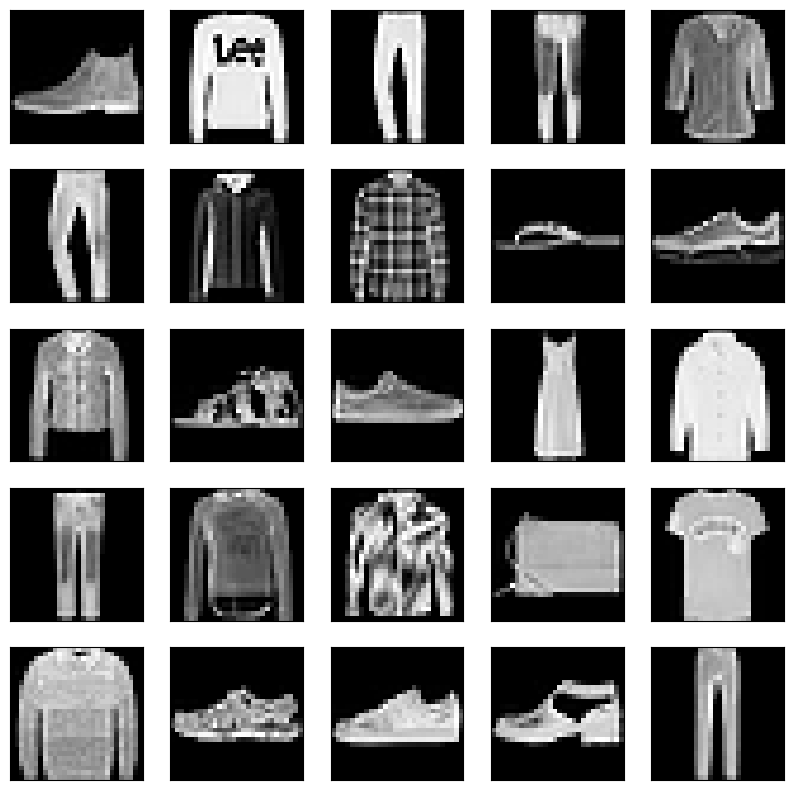

In [ ]:
# display sample images
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test_fashion_mnist[i].reshape(28,28), cmap='gray')

plt.show()

# ACCURACY SCORE
1. 5 Epochs = Test accuracy: 0.9046000242233276
Test Loss: 0.5496127009391785
2. 10 Epochs = Test accuracy: 0.9085000157356262
Test Loss: 0.5142464637756348
3. 20 Epochs = Test accuracy: 0.9063000082969666
Test Loss: 0.2690882682800293